\begin{equation}
\begin{array}{cl}
 \min\limits_{x \in \mathbb{R}^n} & \sum\limits_{i=1}^{n} x_i^2 + \left( \frac{1}{2} \sum\limits_{i=1}^{n} i x_i \right)^2 + \left( \frac{1}{2} \sum\limits_{i=1}^{n} i x_i \right)^4.
\end{array}
\end{equation}

In [9]:
# Load required packages
required_packages = ["LinearAlgebra", "MAT","Random","Zygote","Arpack"]
for pkg in required_packages
    try
        eval(Meta.parse("using $pkg"))
    catch e
        @warn "$pkg not found, installing..."
        import Pkg
        Pkg.add(pkg)
        eval(Meta.parse("using $pkg"))
    end
end

In [10]:
#______________________________________________________________________________#
#             After switching to "Julia" kernel, run this cell                 #
#______________________________________________________________________________#
using LinearAlgebra
using MAT
using Random
using Zygote

#______________________________________________________________________________#
#                           --- Griewank function ---                            #
#______________________________________________________________________________#
Random.seed!(23)

# Define dimensions
n = 1000

# Zakharov function
function f(x)
    n = length(x)
    sum_x2 = sum(x[i]^2 for i in 1:n)
    weighted_sum = 0.5 * sum(i * x[i] for i in 1:n)
    term2 = weighted_sum^2
    term3 = weighted_sum^4
    return sum_x2 + term2 + term3
end

# Gradient via automatic differentiation
grad_f(x) = Zygote.gradient(f, x)[1]

# Generate a random initial point
x0 =  randn(n)

# Linear Minimization Oracle (LMO) unit l2 ball
function lmo(g; tau=1.0)
    norm_g = norm(g, 2)
    return norm_g > 0 ? -tau * g / norm_g : zeros(length(g))
end
#
rho =1
max_iter = 3000
#______________________________________________________________________________#

3000

In [11]:
#______________________________________________________________________________#
#AdaBB: Adaptive Barzilai-Borwein Algorithm#   1
function adabb(f, grad_f, x0, max_iter, alpha0; epsilon=1e-5)
    println("\e[33m____________________AdaBB_________________________")

    # Initialize
    x_prev = copy(x0)
    grad_prev = grad_f(x_prev)
    gap = norm(grad_prev)
    # First step: x^1 = x^0 - alpha_0 * grad f(x^0)
    x = x_prev - alpha0 * grad_prev

    # Compute lambda_1 to determine theta_0
    grad_curr = grad_f(x)
    s_1 = x - x_prev
    y_1 = grad_curr - grad_prev
    lambda_1 = dot(y_1, s_1) / dot(y_1, y_1)

    # Compute theta_0 based on lambda_1
    if lambda_1 >= sqrt(2) * alpha0
        theta0 = lambda_1^2 / (2 * alpha0^2) - 1.0
    else
        theta0 = 0.0
    end

    alpha_km1 = alpha0      # alpha_{k-1}
    theta_km1 = theta0      # theta_{k-1}

    values = [f(x_prev), f(x)]
    times = [0.0]
    gaps = Float64[]
    steps = [alpha0]

    k = 1
    while k < max_iter
        start = time()

        # Reuse grad_curr from theta_0 computation on first iteration
        if k > 1
            grad_curr = grad_f(x)
        end
        if gap <= epsilon
            println(">>>       Terminated at k=$k, Dual Gap: $(round(gap, digits=4))")
            iteration_time = time() - start #  record final time
            push!(times, iteration_time)      #  save final time
            push!(gaps, gap)
            break
        end
        # Compute differences
        s_k = x - x_prev               # x^k - x^{k-1}
        y_k = grad_curr - grad_prev    # grad f(x^k) - grad f(x^{k-1})

        # Compute lambda_k (BB step size)
        lambda_k = dot(y_k, s_k) / dot(y_k, y_k)

        # Adaptive step-size selection
        if lambda_k >= alpha_km1
            alpha_k = sqrt(1 + theta_km1) * alpha_km1
            theta_k = alpha_k / alpha_km1
        elseif alpha_km1 / 2 < lambda_k < alpha_km1
            # Case (i)
            alpha_k = lambda_k
            theta_k = 2 * alpha_k / alpha_km1 - alpha_k / lambda_k
        else
            # Case (iii)
            alpha_k = lambda_k / sqrt(2)
            theta_k = alpha_k / alpha_km1
        end

        # Update iterates
        x_prev = copy(x)
        grad_prev = copy(grad_curr)
        x = x - alpha_k * grad_curr
        k += 1
        # Update for next iteration
        alpha_km1 = alpha_k
        theta_km1 = theta_k

        iteration_time = time() - start
        # ============ END TIMED SECTION ============
        f_curr = f(x)
        gap = norm(grad_prev)
        push!(gaps, gap)
        push!(values, f_curr)
        push!(times, iteration_time)
        push!(steps, alpha_k)

        if k % 100 == 0
            println("k $k: Gap = $(round(gap, digits=6)), alpha_k = $(round(alpha_k, digits=8)), Time = $(round(iteration_time, digits=4)) sec, f_k = $(round(f_curr, digits=6))")
        end
    end

    println("k $k: Gap = $(round(gaps[end], digits=6)), alpha_k = $(round(steps[end], digits=8)), Time = $(round(times[end], digits=4)) sec, f_k = $(round(values[end], digits=6))")
    total_time = sum(times)
    println("AdaBB Method:")
    println("Total time: $(round(total_time, digits=4)) seconds")
    println("Total iterations: $k")
    println("Objective value: $(round(f(x), digits=6))")
    println("____________________________________________________________\e[0m")

    return (x, values, times, gaps, steps)
end

adabb (generic function with 1 method)

In [12]:
#____________________________________Run AdaBB_________________________________#

# Set initial step size
alpha0 = 10^(-10)

# Run AdaBB
results_adabb = adabb(f, grad_f, x0, max_iter, alpha0; epsilon=1e-5)

# Save results
output_dir = "/content/output"
mkpath(output_dir)

MAT.matwrite(joinpath(output_dir, "results_adabb.mat"), Dict(
    "x"      => results_adabb[1],
    "values" => results_adabb[2],
    "times"  => results_adabb[3],
    "gaps"   => results_adabb[4],
    "steps"  => results_adabb[5]
))
println("Saved: ", joinpath(output_dir, "results_adabb.mat"))

____________________AdaBB_________________________
k 100: Gap = 3.380257420656e6, alpha_k = 0.0, Time = 0.0533 sec, f_k = 1209.627948
k 200: Gap = 64.647175, alpha_k = 1.0e-8, Time = 0.0334 sec, f_k = 1044.814243
k 300: Gap = 64.646778, alpha_k = 1.0e-8, Time = 0.0236 sec, f_k = 1044.801339
k 400: Gap = 64.646479, alpha_k = 3.0e-8, Time = 0.0249 sec, f_k = 1044.791673
k 500: Gap = 64.646069, alpha_k = 1.0e-8, Time = 0.0238 sec, f_k = 1044.778518
k 600: Gap = 64.645715, alpha_k = 1.0e-8, Time = 0.0266 sec, f_k = 1044.767081
k 700: Gap = 64.645318, alpha_k = 5.0e-8, Time = 0.035 sec, f_k = 1044.754088
k 800: Gap = 64.644974, alpha_k = 6.0e-8, Time = 0.036 sec, f_k = 1044.742921
k 900: Gap = 64.644634, alpha_k = 8.0e-8, Time = 0.0347 sec, f_k = 1044.731842
k 1000: Gap = 64.64414, alpha_k = 8.0e-8, Time = 0.0238 sec, f_k = 1044.715863
k 1100: Gap = 64.643804, alpha_k = 3.0e-8, Time = 0.0334 sec, f_k = 1044.705223
k 1200: Gap = 64.643486, alpha_k = 8.0e-8, Time = 0.0236 sec, f_k = 1044.6947

In [13]:
using Pkg
Pkg.add(["Plots", "PyPlot", "Measures","PyCall"])

   Resolving package versions...
     Project No packages added to or removed from `~/.julia/environments/v1.12/Project.toml`
    Manifest No packages added to or removed from `~/.julia/environments/v1.12/Manifest.toml`


sys:1: UserWarning: No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored


✅ Saved: Zakharov_L.eps


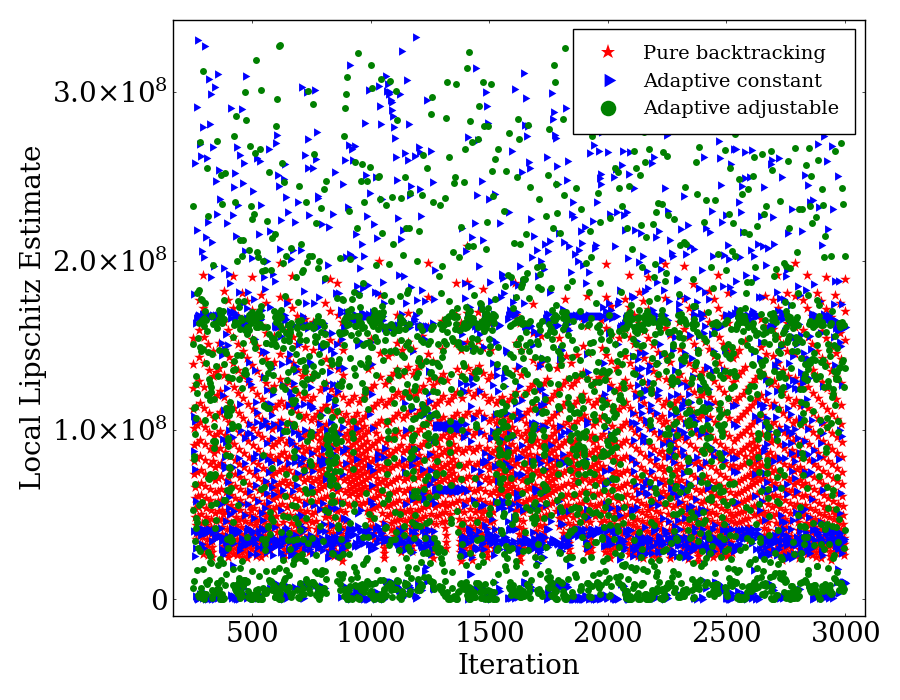

sys:1: UserWarning: No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored
sys:1: UserWarning: No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored
sys:1: UserWarning: No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored
sys:1: UserWarning: No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored


✅ Saved: Zakharov_Gap.eps


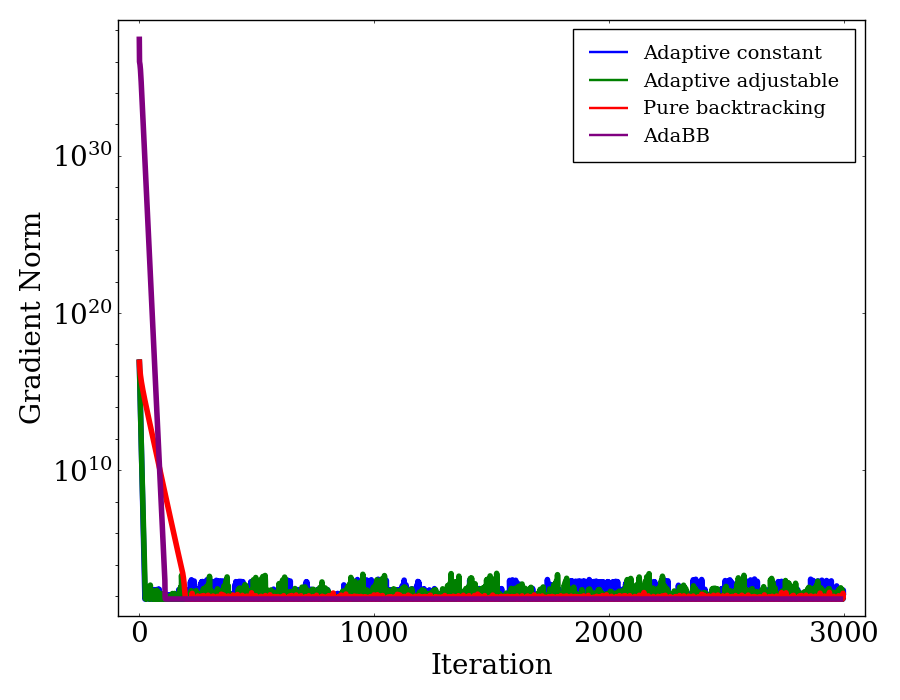

✅ Saved: Zakharov_Gap_vs_time.eps


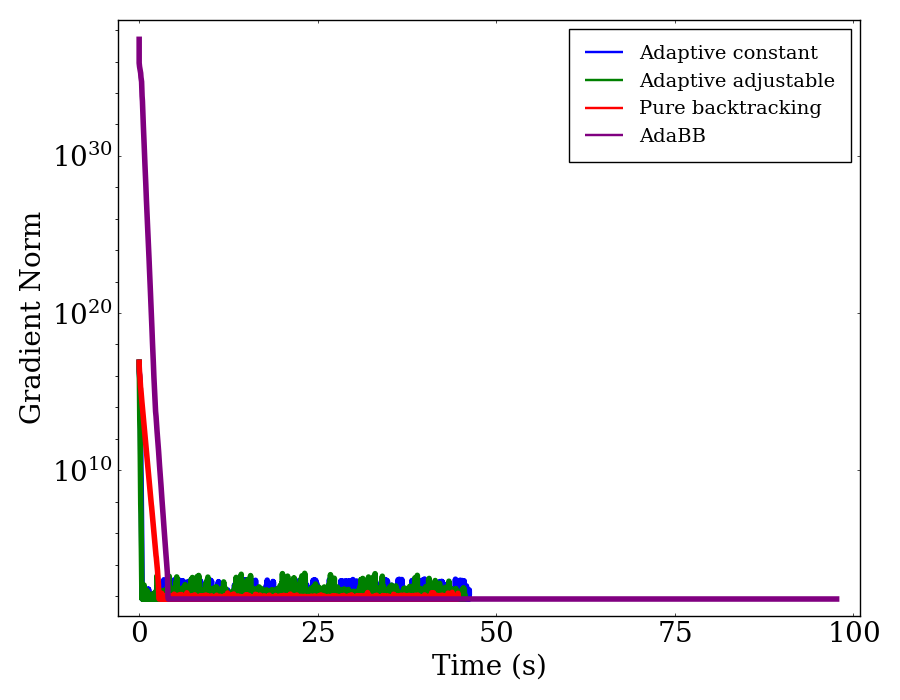


🎉 All plots saved as EPS in: /content/output


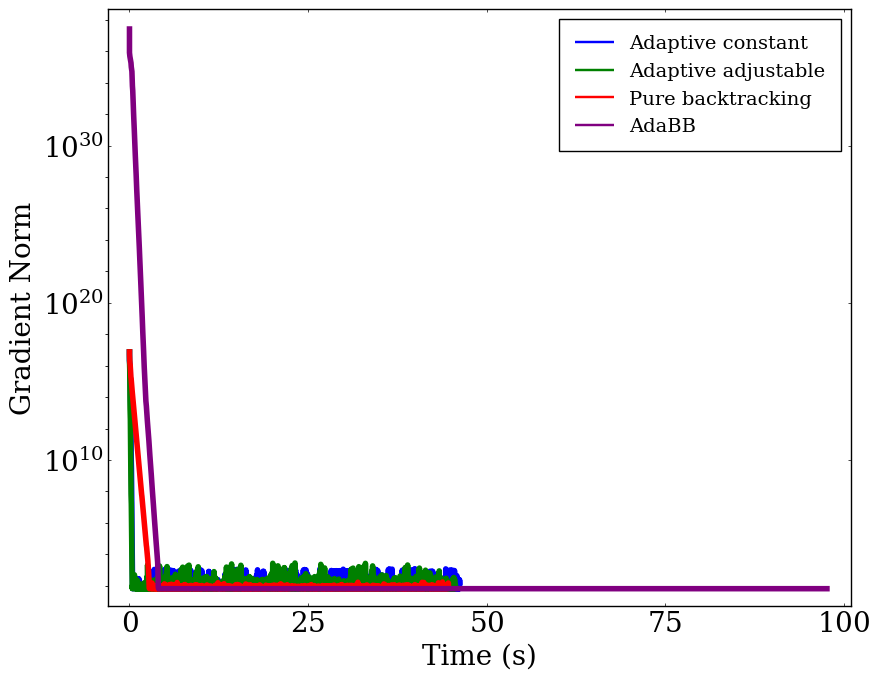

In [14]:
using MAT
using Measures

# Ensure all necessary packages are loaded
using  Plots
using PyPlot
pyplot()

output_dir = "/content/output" # Changed to distinguish from logistic output
mkpath(output_dir)

# --- LOAD DATA ONCE ---
our = matread(joinpath(output_dir, "results_FW_OUR.mat"))
our5 = matread(joinpath(output_dir, "results_FW_OUR_5.mat"))
ped = matread(joinpath(output_dir, "results_FW_Pedregosa.mat"))
ada = matread(joinpath(output_dir, "results_adabb.mat"))

#________________________ PLOTTING FUNCTION (LEGEND ORDER = TABLE ORDER) ________________________#
function create_and_save_plots()
    # --- PREPARE CUMULATIVE TIMES ---
    our_cum_times  = [0.0; cumsum(our["times"][1:end-1])]
    our5_cum_times = [0.0; cumsum(our5["times"][1:end-1])]
    ped_cum_times  = [0.0; cumsum(ped["times"][1:end-1])]
    ada_cum_times  = [0.0; cumsum(ada["times"][1:end-1])]

    # --- STYLE DICTIONARY ---
    style = Dict(
        :titlefont => (20, "serif"),
        :guidefont => (20, "serif"),
        :tickfont => (20, "serif"),
        :legendfont => (14, "serif"),
        :grid => false,
        :framestyle => :box,
        :margin => 5mm,
        :size => (900, 700),
        :linewidth => 2
    )

    # --- PLOT 1: Lipschitz Constants (AdaBB uses step sizes instead) ---
    p1 = Plots.plot()
    start_iter=250
    Plots.plot!(p1, start_iter:length(ped["L_ks"]), ped["L_ks"][start_iter:end],
                label="Pure backtracking",
                color=:red,
                seriestype=:scatter,
                markersize=8,
                marker=:star5,
                markerstrokewidth=0)

    Plots.plot!(p1, start_iter:length(our["L_ks"]), our["L_ks"][start_iter:end],
                label="Adaptive constant",
                color=:blue,
                seriestype=:scatter,
                markersize=7,
                marker=:rtriangle,
                markerstrokewidth=0)

    Plots.plot!(p1, start_iter:length(our5["L_ks"]), our5["L_ks"][start_iter:end],
                label="Adaptive adjustable",
                color=:green,
                seriestype=:scatter,
                markersize=5,
                marker=:circle,
                markerstrokewidth=0)

    Plots.plot!(p1,
            xlabel="Iteration",
            ylabel="Local Lipschitz Estimate";
            style...)

    Plots.savefig(p1, joinpath(output_dir, "Zakharov_L.eps"))
    println("✅ Saved: Zakharov_L.eps")
    display(p1)

    # --- PLOT 2: Gradient Norm vs Iteration ---
    p2 = Plots.plot(our["gaps"],
                    label="Adaptive constant",
                    color=:blue,
                    markerstrokecolor=:blue,
                    markersize=7,
                    yscale=:log10,
                    xlabel="Iteration",
                    ylabel="Gradient Norm";
                    style...)
    Plots.plot!(p2, our["gaps"],
                label=false,
                color=:blue,
                markerstrokecolor=:blue,
                linewidth=4,
                markersize=7)
    Plots.plot!(p2, our5["gaps"],
                    label="Adaptive adjustable",
                    color=:green,
                    markerstrokecolor=:green,
                    linewidth=4,
                    markersize=7)
    Plots.plot!(p2, ped["gaps"],
                    label="Pure backtracking",
                    color=:red,
                    markerstrokecolor=:red,
                    linewidth=4,
                    markersize=7)
    # AdaBB added
    Plots.plot!(p2, ada["gaps"],
                    label="AdaBB",
                    color=:purple,
                    markerstrokecolor=:purple,
                    linewidth=4,
                    markersize=7)

    Plots.savefig(p2, joinpath(output_dir, "Zakharov_Gap.eps"))
    println("✅ Saved: Zakharov_Gap.eps")
    display(p2)

    # --- PLOT 3: Gradient Norm vs Time ---
    p3 = Plots.plot(our_cum_times[1:end-1], our["gaps"],
                    label="Adaptive constant",
                    color=:blue,
                    markerstrokecolor=:blue,
                    yscale=:log10,
                    xlabel="Time (s)",
                    ylabel="Gradient Norm",
                    markersize=7;
                    style...)
    Plots.plot!(p3, our_cum_times[1:end-1], our["gaps"],
                label=false,
                color=:blue,
                markerstrokecolor=:blue,
                linewidth=4,
                markersize=7)
    Plots.plot!(p3, our5_cum_times[1:end-1], our5["gaps"],
                    label="Adaptive adjustable",
                    color=:green,
                    markerstrokecolor=:green,
                    linewidth=4,
                    markersize=7)
    Plots.plot!(p3, ped_cum_times[1:end-1], ped["gaps"],
                    label="Pure backtracking",
                    color=:red,
                    markerstrokecolor=:red,
                    linewidth=4,
                    markersize=7)
    # AdaBB added
    Plots.plot!(p3, ada_cum_times[1:end-1], ada["gaps"],
                    label="AdaBB",
                    color=:purple,
                    markerstrokecolor=:purple,
                    linewidth=4,
                    markersize=7)

    Plots.savefig(p3, joinpath(output_dir, "Zakharov_Gap_vs_time.eps"))
    println("✅ Saved: Zakharov_Gap_vs_time.eps")
    display(p3)

    println("\n🎉 All plots saved as EPS in: $output_dir")
end

# --- RUN PLOTTING ---
create_and_save_plots()

In [15]:
# Step 1: Zip the correct output folder
try
    run(`zip -r /content/output.zip /content/output`)
    println("Zipping successful!")
catch e
    println("Error during zipping: ", e)
end

# Step 2: Prepare to download the file
using PyCall

# Import the Python module *before* the try...catch block
@pyimport google.colab.files as colab_files

# Step 3: Trigger the download
try
    println("Preparing to download...")
    println("Please check your browser to confirm the download.")
    # Download the correctly named zip file
    colab_files.download("/content/output.zip")
catch e
    println("Error during download: ", e)
    println("Please ensure you are running this in a Google Colab environment.")

  adding: content/output/ (stored 0%)
  adding: content/output/results_FW_OUR.mat (deflated 34%)
  adding: content/output/results_FW_OUR_5.mat (deflated 34%)
  adding: content/output/results_adabb.mat (deflated 31%)
  adding: content/output/.ipynb_checkpoints/ (stored 0%)
  adding: content/output/Zakharov_Gap.eps (deflated 60%)
  adding: content/output/results_FW_Pedregosa.mat (deflated 36%)
  adding: content/output/Zakharov_Gap_vs_time.eps (deflated 61%)
  adding: content/output/Zakharov_L.eps (deflated 62%)
Zipping successful!


LoadError: ParseError:
[90m# Error @ [0;0m]8;;file:///content/In[15]#23:81\[90mIn[15]:23:81[0;0m]8;;\
    println("Error during download: ", e)
    println("Please ensure you are running this in a Google Colab environment.")[48;2;120;70;70m[0;0m
[90m#                                                                               └ ── [0;0m[91mExpected `end`[0;0m